# 中国汽车市场销量分析

本 Notebook 使用真实公开的中国汽车车型月度销量数据，完整展示原始数据读取、质量检查、Python 清洗、指标计算、可视化和业务结论。

- 数据范围：2018-01 至 2024-04
- 数据来源：[Kaggle - China Automobile Monthly Sales Data](https://www.kaggle.com/datasets/felixzhao/china-automobile-monthly-sales-data-2018-2024-4)
- 数据性质：公开整理数据，非模拟生成

In [1]:
from pathlib import Path
import hashlib
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
RAW_FILE = PROJECT_ROOT / "data" / "China Automobile Sales Data.csv"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

print("项目目录：", PROJECT_ROOT)
print("Python数据分析环境已加载")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\LENOVO\\AppData\\Local\\matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


项目目录： C:\Users\LENOVO\Desktop\中国汽车市场销量分析项目-精简版（待检查）
Python数据分析环境已加载


## 1. 原始数据与来源校验

In [2]:
def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest().upper()

raw = pd.read_csv(RAW_FILE, encoding="utf-8")
source_check = pd.DataFrame({
    "检查项": ["原始文件", "文件大小（字节）", "SHA256", "原始行数", "原始字段数"],
    "结果": [RAW_FILE.name, RAW_FILE.stat().st_size, file_sha256(RAW_FILE), len(raw), len(raw.columns)],
})
source_check

,检查项,结果
0,原始文件,China Automobile Sales Data.csv
1,文件大小（字节）,3355240
2,SHA256,915196C7BAFF84DB57397D8A165BBCED4EFB892E7C7959...
3,原始行数,38806
4,原始字段数,10


In [3]:
raw.head(10)

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
0,Model Y,69098,特斯拉中国,316.9,417.9,2022-11-01,EV,SUV,Tesla,United States
1,宏光MINIEV,68567,上汽通用五菱,32.8,99.9,2022-11-01,EV,Hatchback,Wuling Motors,China
2,宋PLUS新能源,64145,比亚迪,152.8,216.8,2022-11-01,EV,SUV,BYD,China
3,汉,31786,比亚迪,214.8,329.8,2022-11-01,EV,Sedan,BYD,China
4,Model 3,31193,特斯拉中国,266.7,339.9,2022-11-01,EV,Sedan,Tesla,United States
5,元PLUS,29402,比亚迪,137.8,165.8,2022-11-01,EV,SUV,BYD,China
6,朗逸,28867,上汽大众,100.9,159.9,2022-11-01,Gasoline,Hatchback,Volkswagen,Germany
7,海豚,26063,比亚迪,102.8,136.8,2022-11-01,EV,Hatchback,BYD,China
8,秦PLUS,25498,比亚迪,111.8,175.8,2022-11-01,EV,Sedan,BYD,China
9,轩逸,24929,东风日产,99.8,174.9,2022-11-01,Gasoline,Sedan,Nissan,Japan


## 2. 数据质量检查

In [4]:
quality_before = pd.DataFrame({
    "检查项目": [
        "完全重复行", "车型类别缺失", "日期无法解析", "销量小于等于0",
        "最低价高于最高价", "价格为0"
    ],
    "数量": [
        int(raw.duplicated().sum()),
        int(raw["body_type"].isna().sum()),
        int(pd.to_datetime(raw["year_month"], errors="coerce").isna().sum()),
        int((pd.to_numeric(raw["units_sold"], errors="coerce") <= 0).sum()),
        int((raw["low_price"] > raw["high_price"]).sum()),
        int(((raw["low_price"] == 0) | (raw["high_price"] == 0)).sum()),
    ],
})
quality_before

,检查项目,数量
0,完全重复行,33
1,车型类别缺失,2366
2,日期无法解析,0
3,销量小于等于0,0
4,最低价高于最高价,0
5,价格为0,6127


质量检查发现 33 条完全重复记录、2,366 条车型类别缺失和 6,127 条零价格记录。零价格代表网站未提供可用售价，不用 0 代替实际价格；后续价格带分析将它标记为“价格缺失”。

## 3. Python 清洗与特征构造

In [5]:
def normalize_text(value):
    return re.sub(r"\s+", " ", str(value)).strip()

brand_normalization = {"Shenlan": "Deepal", "Byton": "Denza", "LanTu": "Voyah"}
ev_only_brands = {
    "Aiways", "Deepal", "Denza", "GAC Aion", "Geometry", "Hozon",
    "Leapmotor", "Li Auto", "NIO", "Ora", "Polestar", "SERES",
    "Tesla", "Voyah", "WM Motor", "XPeng Motors", "Zeekr"
}
body_type_cn = {
    "SUV": "SUV", "Sedan": "轿车", "Hatchback": "两厢车",
    "MPV": "MPV", "Sports Car": "跑车", "Unknown": "未知"
}

clean = raw.drop_duplicates().copy()
for col in ["model", "make", "is_ev", "body_type", "brand", "brand_country"]:
    clean[col] = clean[col].fillna("Unknown").map(normalize_text)

clean["brand_raw"] = clean["brand"]
clean["is_ev_raw"] = clean["is_ev"]
clean["brand"] = clean["brand"].replace(brand_normalization)
energy_correction = clean["brand"].isin(ev_only_brands) & ~clean["is_ev"].eq("EV")
clean["energy_label_corrected"] = energy_correction
clean.loc[energy_correction, "is_ev"] = "EV"

clean["year_month"] = pd.to_datetime(clean["year_month"], errors="coerce")
clean["units_sold"] = pd.to_numeric(clean["units_sold"], errors="coerce")
clean["low_price"] = pd.to_numeric(clean["low_price"], errors="coerce").round(1)
clean["high_price"] = pd.to_numeric(clean["high_price"], errors="coerce").round(1)
clean = clean.loc[clean["year_month"].notna() & clean["units_sold"].gt(0)].copy()
clean["units_sold"] = clean["units_sold"].astype("int64")

valid_price = clean["low_price"].gt(0) & clean["high_price"].gt(0)
clean["avg_price_k_rmb"] = np.where(
    valid_price, (clean["low_price"] + clean["high_price"]) / 2, np.nan
).round(1)
clean["energy_type"] = clean["is_ev"].map({"EV": "新能源", "Gasoline": "燃油"}).fillna("未知")
clean["body_type_cn"] = clean["body_type"].map(body_type_cn).fillna(clean["body_type"])
clean["brand_origin"] = np.where(clean["brand_country"].eq("China"), "中国品牌", "海外品牌")
clean["price_band"] = pd.cut(
    clean["avg_price_k_rmb"], [-np.inf, 100, 150, 200, 300, np.inf],
    labels=["10万元以下", "10–15万元", "15–20万元", "20–30万元", "30万元以上"]
).astype("string").fillna("价格缺失")
clean["year"] = clean["year_month"].dt.year
clean["month"] = clean["year_month"].dt.month
clean["year_month_label"] = clean["year_month"].dt.strftime("%Y-%m")

pd.DataFrame({
    "指标": ["清洗前行数", "清洗后行数", "删除重复行", "填补车型类别缺失", "能源标签规则修正"],
    "结果": [len(raw), len(clean), len(raw) - len(clean), raw["body_type"].isna().sum(), energy_correction.sum()],
})

,指标,结果
0,清洗前行数,38806
1,清洗后行数,38773
2,删除重复行,33
3,填补车型类别缺失,2366
4,能源标签规则修正,327


In [6]:
clean.head(10)

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country,...,is_ev_raw,energy_label_corrected,avg_price_k_rmb,energy_type,body_type_cn,brand_origin,price_band,year,month,year_month_label
0,Model Y,69098,特斯拉中国,316.9,417.9,2022-11-01,EV,SUV,Tesla,United States,...,EV,False,367.4,新能源,SUV,海外品牌,30万元以上,2022,11,2022-11
1,宏光MINIEV,68567,上汽通用五菱,32.8,99.9,2022-11-01,EV,Hatchback,Wuling Motors,China,...,EV,False,66.4,新能源,两厢车,中国品牌,10万元以下,2022,11,2022-11
2,宋PLUS新能源,64145,比亚迪,152.8,216.8,2022-11-01,EV,SUV,BYD,China,...,EV,False,184.8,新能源,SUV,中国品牌,15–20万元,2022,11,2022-11
3,汉,31786,比亚迪,214.8,329.8,2022-11-01,EV,Sedan,BYD,China,...,EV,False,272.3,新能源,轿车,中国品牌,20–30万元,2022,11,2022-11
4,Model 3,31193,特斯拉中国,266.7,339.9,2022-11-01,EV,Sedan,Tesla,United States,...,EV,False,303.3,新能源,轿车,海外品牌,30万元以上,2022,11,2022-11
5,元PLUS,29402,比亚迪,137.8,165.8,2022-11-01,EV,SUV,BYD,China,...,EV,False,151.8,新能源,SUV,中国品牌,15–20万元,2022,11,2022-11
6,朗逸,28867,上汽大众,100.9,159.9,2022-11-01,Gasoline,Hatchback,Volkswagen,Germany,...,Gasoline,False,130.4,燃油,两厢车,海外品牌,10–15万元,2022,11,2022-11
7,海豚,26063,比亚迪,102.8,136.8,2022-11-01,EV,Hatchback,BYD,China,...,EV,False,119.8,新能源,两厢车,中国品牌,10–15万元,2022,11,2022-11
8,秦PLUS,25498,比亚迪,111.8,175.8,2022-11-01,EV,Sedan,BYD,China,...,EV,False,143.8,新能源,轿车,中国品牌,10–15万元,2022,11,2022-11
9,轩逸,24929,东风日产,99.8,174.9,2022-11-01,Gasoline,Sedan,Nissan,Japan,...,Gasoline,False,137.4,燃油,轿车,海外品牌,10–15万元,2022,11,2022-11


## 4. 月度市场指标

In [7]:
monthly = clean.groupby("year_month", as_index=False).agg(
    total_units=("units_sold", "sum"),
    model_count=("model", "nunique"),
    make_count=("make", "nunique"),
)
ev_monthly = clean[clean["energy_type"].eq("新能源")].groupby("year_month")["units_sold"].sum()
domestic_monthly = clean[clean["brand_origin"].eq("中国品牌")].groupby("year_month")["units_sold"].sum()
monthly["ev_units"] = monthly["year_month"].map(ev_monthly).fillna(0)
monthly["domestic_units"] = monthly["year_month"].map(domestic_monthly).fillna(0)
monthly["ev_share"] = monthly["ev_units"] / monthly["total_units"]
monthly["domestic_share"] = monthly["domestic_units"] / monthly["total_units"]
monthly["mom_growth"] = monthly["total_units"].pct_change()
monthly["yoy_growth"] = monthly["total_units"].pct_change(12)
monthly.tail(12)

,year_month,total_units,model_count,make_count,ev_units,domestic_units,ev_share,domestic_share,mom_growth,yoy_growth
64,2023-05-01,1685966,543,98,536706,871329,0.318337,0.516813,0.030546,0.069059
65,2023-06-01,1884377,542,99,615431,924831,0.326597,0.490789,0.117684,-0.130003
66,2023-07-01,1781580,553,98,582981,947226,0.327227,0.531677,-0.054552,-0.161963
67,2023-08-01,1922457,548,98,661341,995320,0.344008,0.517733,0.079074,-0.133960
68,2023-09-01,2019442,554,97,674593,1076735,0.334049,0.533184,0.050448,-0.112526
69,2023-10-01,2032470,549,95,673381,1128899,0.331312,0.555432,0.006451,-0.064401
70,2023-11-01,2076783,549,97,729205,1146178,0.351122,0.551901,0.021803,0.034563
71,2023-12-01,2360143,566,97,800220,1240631,0.339056,0.525659,0.136442,0.077265
72,2024-01-01,2034527,553,94,533498,1119128,0.262222,0.550068,-0.137965,0.570946
73,2024-02-01,1111515,539,95,323842,619251,0.291352,0.557123,-0.453674,-0.204071


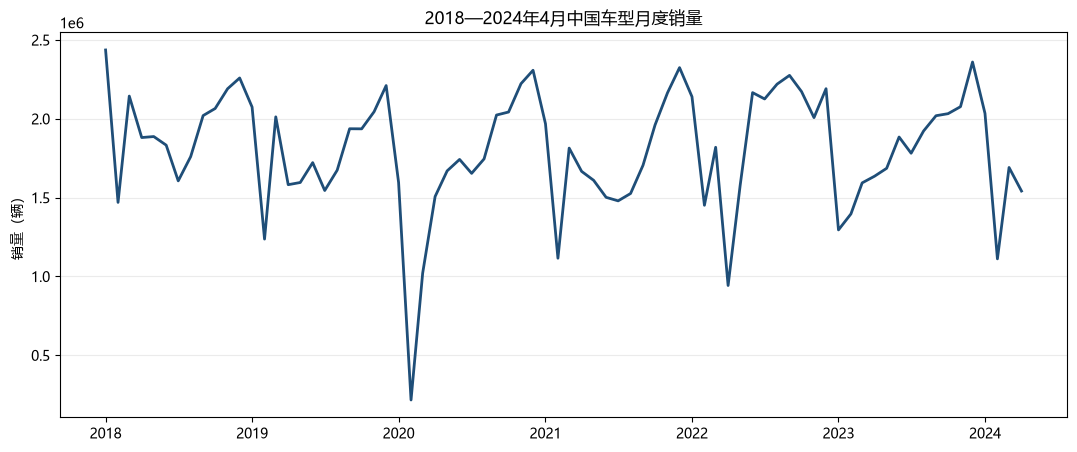

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["year_month"], monthly["total_units"], color="#1F4E78", linewidth=2)
ax.set_title("2018—2024年4月中国车型月度销量")
ax.set_ylabel("销量（辆）")
ax.grid(axis="y", alpha=0.25)
plt.show()

## 5. 新能源和中国品牌份额

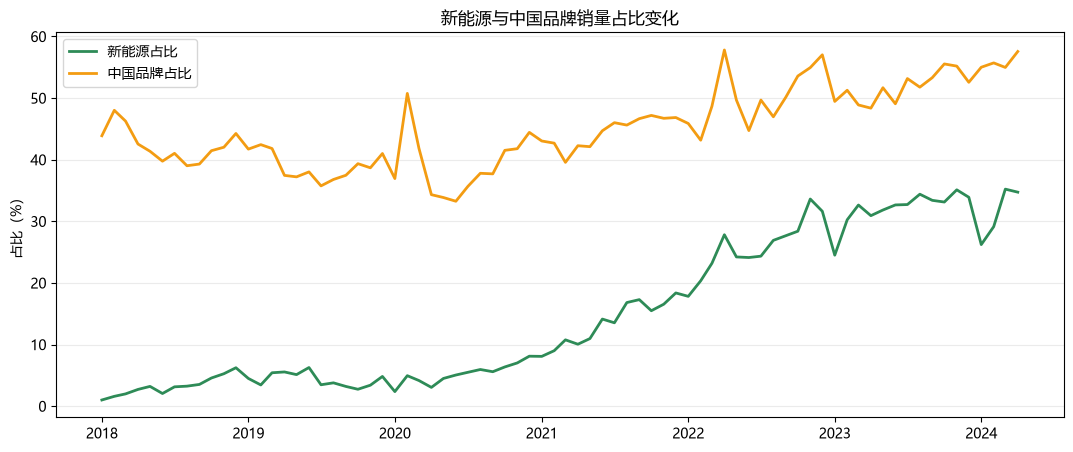

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["year_month"], monthly["ev_share"] * 100, label="新能源占比", color="#2E8B57", linewidth=2)
ax.plot(monthly["year_month"], monthly["domestic_share"] * 100, label="中国品牌占比", color="#F39C12", linewidth=2)
ax.set_title("新能源与中国品牌销量占比变化")
ax.set_ylabel("占比（%）")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

## 6. 最近12个月品牌表现

In [10]:
current_end = clean["year_month"].max()
current_start = current_end - pd.DateOffset(months=11)
prior_end = current_start - pd.DateOffset(months=1)
prior_start = prior_end - pd.DateOffset(months=11)

current = clean[clean["year_month"].between(current_start, current_end)]
prior = clean[clean["year_month"].between(prior_start, prior_end)]
brand_current = current.groupby("brand")["units_sold"].sum().rename("最近12个月销量")
brand_prior = prior.groupby("brand")["units_sold"].sum().rename("上一个12个月销量")
brand_compare = pd.concat([brand_current, brand_prior], axis=1).fillna(0)
brand_compare["同比增长率"] = np.where(
    brand_compare["上一个12个月销量"].gt(0),
    brand_compare["最近12个月销量"] / brand_compare["上一个12个月销量"] - 1,
    np.nan,
)
brand_compare["市场份额"] = brand_compare["最近12个月销量"] / brand_compare["最近12个月销量"].sum()
brand_compare = brand_compare.sort_values("最近12个月销量", ascending=False)
brand_compare.head(15).style.format({"同比增长率": "{:.1%}", "市场份额": "{:.1%}"})

,最近12个月销量,上一个12个月销量,同比增长率,市场份额
brand,,,,
BYD,2686437.000000,2120349.000000,26.7%,12.1%
Volkswagen,2230767.000000,2343542.000000,-4.8%,10.1%
Toyota,1637832.000000,1828397.000000,-10.4%,7.4%
Honda,1202043.000000,1278037.000000,-5.9%,5.4%
Changan,1191628.000000,1202715.000000,-0.9%,5.4%
Geely Automobile,1099035.000000,974948.000000,12.7%,5.0%
Chery,832149.000000,967224.000000,-14.0%,3.8%
Wuling Motors,825998.000000,1167679.000000,-29.3%,3.7%
Great Wall,770658.000000,773987.000000,-0.4%,3.5%


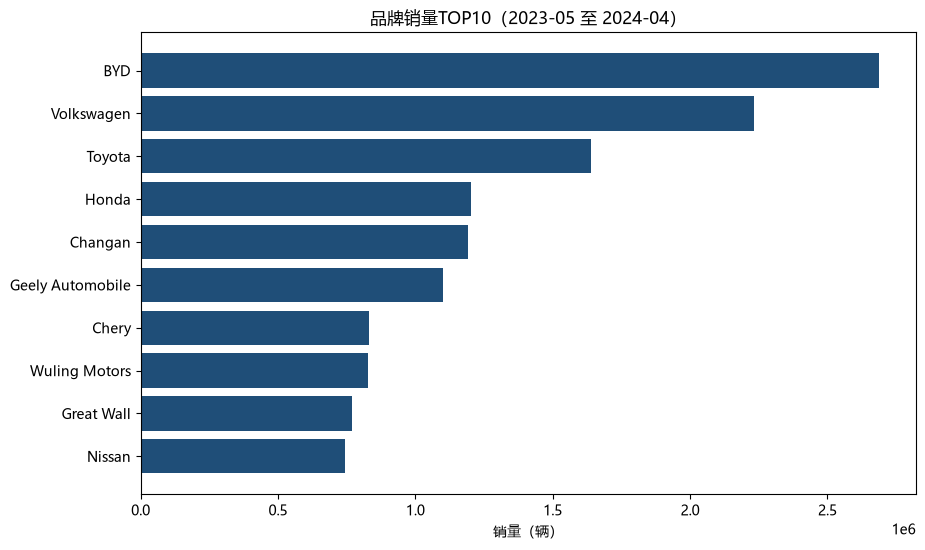

In [11]:
top10 = brand_compare.head(10).sort_values("最近12个月销量")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10.index, top10["最近12个月销量"], color="#1F4E78")
ax.set_title(f"品牌销量TOP10（{current_start:%Y-%m} 至 {current_end:%Y-%m}）")
ax.set_xlabel("销量（辆）")
plt.show()

## 7. 车型增长与价格带结构

In [12]:
model_current = current.groupby("model")["units_sold"].sum().rename("最近12个月销量")
model_prior = prior.groupby("model")["units_sold"].sum().rename("上一个12个月销量")
model_compare = pd.concat([model_current, model_prior], axis=1).fillna(0)
model_compare["同比增长率"] = np.where(
    model_compare["上一个12个月销量"].gt(0),
    model_compare["最近12个月销量"] / model_compare["上一个12个月销量"] - 1,
    np.nan,
)
model_compare = model_compare.sort_values("最近12个月销量", ascending=False)

price_summary = current.groupby("price_band", observed=True)["units_sold"].sum().sort_values(ascending=False)
display(model_compare.head(15).style.format({"同比增长率": "{:.1%}"}))
display(price_summary.to_frame("销量"))

,最近12个月销量,上一个12个月销量,同比增长率
model,,,
秦PLUS,468826.000000,343195.000000,36.6%
Model Y,461709.000000,470048.000000,-1.8%
轩逸,380561.000000,385586.000000,-1.3%
宋PLUS新能源,374752.000000,490138.000000,-23.5%
海鸥,338386.000000,0.000000,nan%
朗逸,335882.000000,379676.000000,-11.5%
元PLUS,288695.000000,266875.000000,8.2%
速腾,287090.000000,204905.000000,40.1%
长安CS75 PLUS,256125.000000,227601.000000,12.5%


,销量
price_band,
10–15万元,5866298
30万元以上,4510789
15–20万元,4508773
20–30万元,4449293
10万元以下,2776647
价格缺失,30333


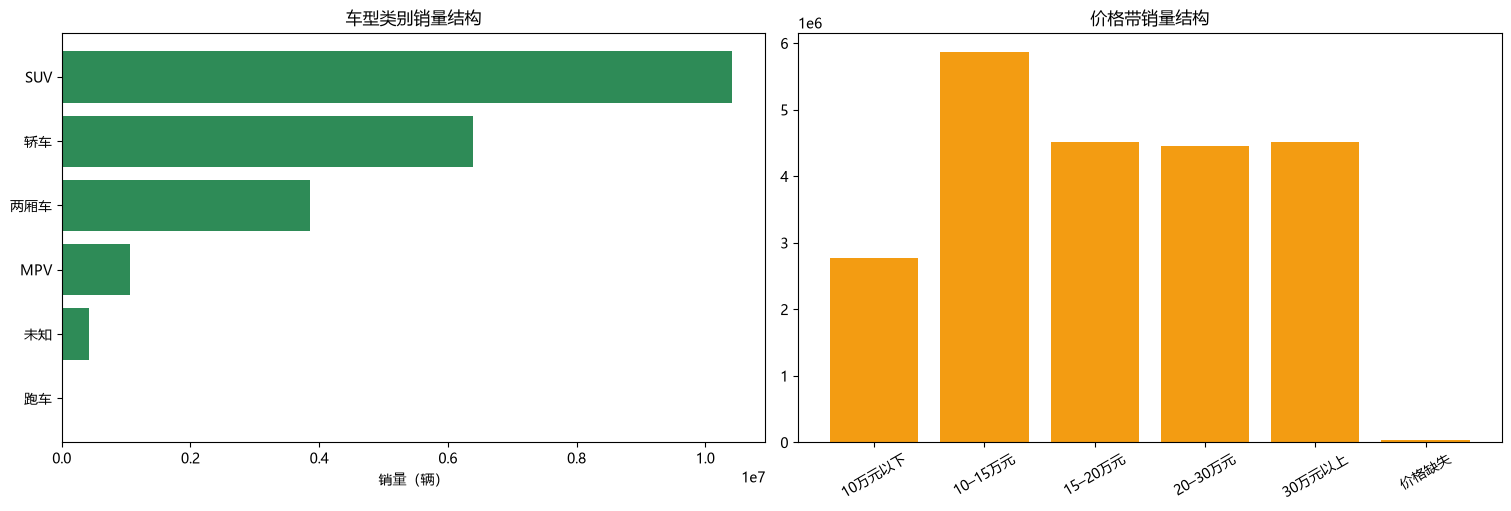

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
body = current.groupby("body_type_cn")["units_sold"].sum().sort_values()
axes[0].barh(body.index, body.values, color="#2E8B57")
axes[0].set_title("车型类别销量结构")
axes[0].set_xlabel("销量（辆）")

price_order = ["10万元以下", "10–15万元", "15–20万元", "20–30万元", "30万元以上", "价格缺失"]
price = current.groupby("price_band")["units_sold"].sum().reindex(price_order).fillna(0)
axes[1].bar(price.index, price.values, color="#F39C12")
axes[1].set_title("价格带销量结构")
axes[1].tick_params(axis="x", rotation=30)
plt.show()

## 8. 核心结论与数据限制

In [14]:
from IPython.display import Markdown, display
conclusion_text = """
### 核心业务结论

- 最近12个月样本销量同比下降2.3%，市场竞争正在由行业增量转向结构性竞争。
- 新能源销量占比由28.2%上升至32.8%，是最明确的结构性增长来源。
- 中国品牌份额由50.5%上升至53.7%，整体竞争优势继续扩大。
- BYD为最近12个月销量最高品牌，前五品牌合计占40.4%，头部品牌集中度较高。
- 秦PLUS为最近12个月销量最高车型，车型资源配置应结合规模、增速和历史基数综合判断。
"""
display(Markdown(conclusion_text))


### 核心业务结论

- 最近12个月样本销量同比下降2.3%，市场竞争正在由行业增量转向结构性竞争。
- 新能源销量占比由28.2%上升至32.8%，是最明确的结构性增长来源。
- 中国品牌份额由50.5%上升至53.7%，整体竞争优势继续扩大。
- BYD为最近12个月销量最高品牌，前五品牌合计占40.4%，头部品牌集中度较高。
- 秦PLUS为最近12个月销量最高车型，车型资源配置应结合规模、增速和历史基数综合判断。


## 9. 可复现输出检查

In [15]:
output_files = sorted(
    str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
    for path in PROJECT_ROOT.rglob("*")
    if path.is_file() and path.name != "中国汽车市场销量分析.ipynb"
)
pd.DataFrame({"已生成文件": output_files})

,已生成文件
0,README.md
1,data/China Automobile Sales Data.csv
2,data/china_auto_sales_clean.csv
3,data/china_auto_sales_tableau.csv
4,pipeline.py
5,requirements.txt
6,中国汽车市场销量分析.twbx
